# 03 — Modelo Predictivo de Temperatura

**Objetivo:** Construir un modelo de regresión lineal que estime la anomalía
de temperatura global para los próximos 3 años (2027–2029), usando datos
históricos de CO₂ y año como variables predictoras.

**Pregunta de negocio:** Con base en los datos históricos de temperatura y
emisiones, ¿es posible construir un modelo que estime la temperatura promedio
para los próximos 3 años?

**Modelo elegido:** Regresión Lineal (scikit-learn)  
**Variables predictoras (X):** año, CO₂ en ppm  
**Variable objetivo (y):** anomalía de temperatura (°C)  
**Período de predicción:** 2027, 2028 y 2029

In [1]:
#Imports y carga de datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120

from google.colab import drive
drive.mount('/content/drive')

ruta_clean = '/content/drive/MyDrive/Proyecto_Clima/ data/clean/'
ruta_plots = '/content/drive/MyDrive/Proyecto_Clima/plots/'

df_global = pd.read_csv(ruta_clean + 'temp_global_clean.csv', parse_dates=['date'])
print("✅ Datos cargados")
print(df_global.shape)
print(df_global.head(3))

Mounted at /content/drive
✅ Datos cargados
(316, 6)
   year  month  region  temp_anomaly_c  co2_ppm       date
0  2000      1  Global           0.432   367.44 2000-01-01
1  2000      2  Global           0.451   369.21 2000-02-01
2  2000      3  Global           0.428   371.01 2000-03-01


In [2]:
#  Preparamos los datos para el modelo

# Promedio anual — el modelo trabaja con datos anuales
df_model = df_global.groupby('year')[['temp_anomaly_c', 'co2_ppm']].mean().reset_index()
df_model = df_model.dropna()  # eliminar filas sin co2_ppm

print(f"Datos disponibles para el modelo: {df_model.shape[0]} años")
print(df_model)

Datos disponibles para el modelo: 27 años
    year  temp_anomaly_c     co2_ppm
0   2000        0.448500  369.325833
1   2001        0.511250  371.489167
2   2002        0.613250  373.339167
3   2003        0.651667  375.241667
4   2004        0.555917  377.140000
5   2005        0.628417  379.031667
6   2006        0.637917  380.693333
7   2007        0.643667  382.788333
8   2008        0.606583  384.545833
9   2009        0.614333  386.580833
10  2010        0.683000  388.406667
11  2011        0.588000  390.367500
12  2012        0.601667  392.339167
13  2013        0.672250  394.080833
14  2014        0.715417  401.710000
15  2015        0.887250  404.425833
16  2016        1.028667  407.193333
17  2017        0.976000  409.738333
18  2018        0.899250  412.588333
19  2019        0.922417  415.224167
20  2020        0.949667  417.909167
21  2021        0.840167  420.555000
22  2022        0.764833  423.325833
23  2023        1.133167  425.907500
24  2024        1.312917  428.654

In [3]:
# Dividimos datos en entrenamiento y prueba

# Variables predictoras y objetivo
X = df_model[['year', 'co2_ppm']]
y = df_model['temp_anomaly_c']

# Dividir: 80% entrenamiento, 20% prueba
# Sin shuffle porque son series de tiempo — el orden importa
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Entrenamiento: {len(X_train)} años ({X_train['year'].min()}–{X_train['year'].max()})")
print(f"Prueba:        {len(X_test)} años ({X_test['year'].min()}–{X_test['year'].max()})")

Entrenamiento: 21 años (2000–2020)
Prueba:        6 años (2021–2026)


In [4]:
#  Entrenamos el modelo

modelo = LinearRegression()
modelo.fit(X_train, y_train)

print("✅ Modelo entrenado")
print(f"Coeficiente año:     {modelo.coef_[0]:.4f}")
print(f"Coeficiente co2_ppm: {modelo.coef_[1]:.4f}")
print(f"Intercepto:          {modelo.intercept_:.4f}")

✅ Modelo entrenado
Coeficiente año:     -0.0396
Coeficiente co2_ppm: 0.0257
Intercepto:          70.2295


In [5]:
# Evaluamos el modelo

y_pred = modelo.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("MÉTRICAS DE EVALUACIÓN")
print("="*35)
print(f"R²:   {r2:.4f}  → el modelo explica el {r2*100:.1f}% de la variación")
print(f"MAE:  {mae:.4f} → error promedio de {mae:.3f}°C")
print(f"RMSE: {rmse:.4f} → error cuadrático medio de {rmse:.3f}°C")

MÉTRICAS DE EVALUACIÓN
R²:   0.3314  → el modelo explica el 33.1% de la variación
MAE:  0.1399 → error promedio de 0.140°C
RMSE: 0.1693 → error cuadrático medio de 0.169°C


In [6]:
# Predicción 2027 - 2029

# Estimar CO₂ futuro basado en incremento promedio histórico
incremento_co2 = df_model['co2_ppm'].diff().mean()
ultimo_co2 = df_model['co2_ppm'].iloc[-1]

futuros = pd.DataFrame({
    'year': [2027, 2028, 2029],
    'co2_ppm': [
        ultimo_co2 + incremento_co2,
        ultimo_co2 + incremento_co2 * 2,
        ultimo_co2 + incremento_co2 * 3
    ]
})

futuros['temp_predicha'] = modelo.predict(futuros[['year', 'co2_ppm']])

print("PREDICCIONES 2027–2029")
print("="*45)
for _, row in futuros.iterrows():
    print(f"{int(row['year'])}: {row['temp_predicha']:.3f}°C  (CO₂ estimado: {row['co2_ppm']:.1f} ppm)")

PREDICCIONES 2027–2029
2027: 1.212°C  (CO₂ estimado: 437.1 ppm)
2028: 1.237°C  (CO₂ estimado: 439.6 ppm)
2029: 1.262°C  (CO₂ estimado: 442.1 ppm)


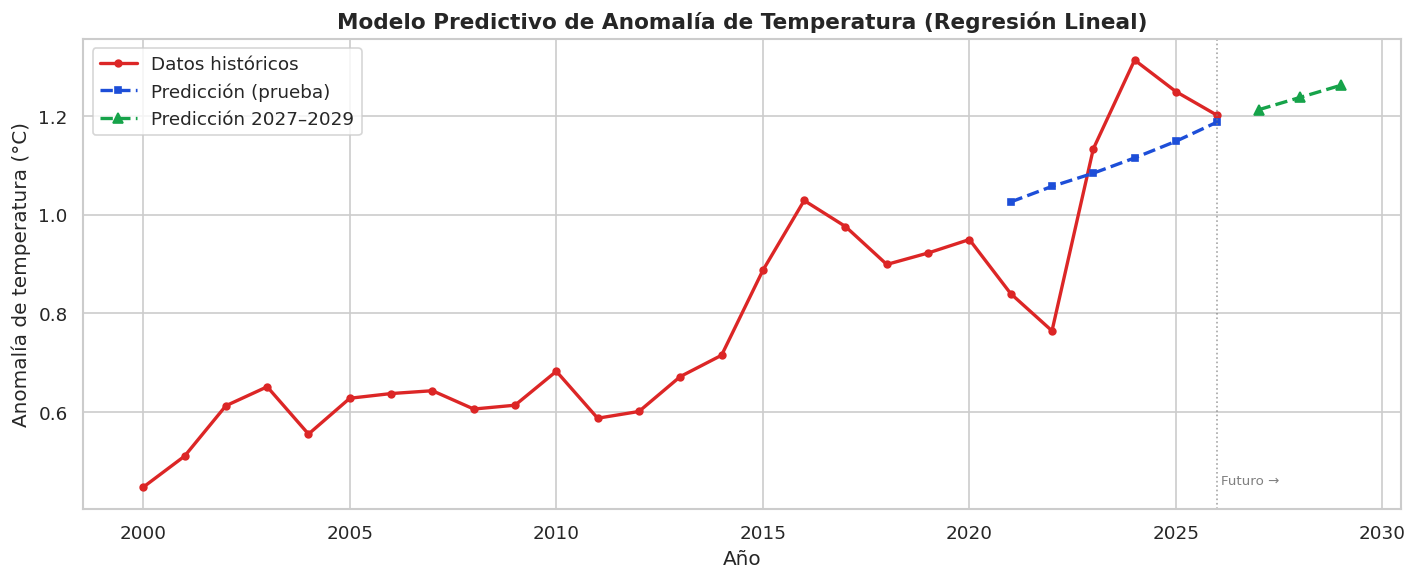

In [7]:
# Grafica del modelo

fig, ax = plt.subplots()

# Datos históricos
ax.plot(df_model['year'], df_model['temp_anomaly_c'],
        color='#dc2626', linewidth=2, marker='o', markersize=4, label='Datos históricos')

# Predicción sobre datos de prueba
ax.plot(X_test['year'], y_pred,
        color='#1d4ed8', linewidth=2, linestyle='--', marker='s',
        markersize=4, label='Predicción (prueba)')

# Predicción futura
ax.plot(futuros['year'], futuros['temp_predicha'],
        color='#16a34a', linewidth=2, linestyle='--', marker='^',
        markersize=6, label='Predicción 2027–2029')

# Separador entre histórico y futuro
ax.axvline(2026, color='gray', linewidth=1, linestyle=':', alpha=0.7)
ax.text(2026.1, ax.get_ylim()[0] + 0.05, 'Futuro →', fontsize=8, color='gray')

ax.set_title('Modelo Predictivo de Anomalía de Temperatura (Regresión Lineal)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Anomalía de temperatura (°C)')
ax.legend()
plt.tight_layout()
plt.savefig(ruta_plots + 'plot_05_modelo_predictivo.png', dpi=150)
plt.show()

## Hallazgo 5 — Modelo Predictivo (Regresión Lineal)

### Métricas del modelo
| Métrica | Valor | Interpretación |
|---|---|---|
| R² (prueba) | 0.33 | Explica el 33% de la variación en datos no vistos |
| MAE | 0.140°C | Error promedio de ±0.14°C por año |
| RMSE | 0.169°C | Penaliza más los errores grandes |

### Predicciones 2027–2029
| Año | CO₂ estimado | Temperatura predicha |
|---|---|---|
| 2027 | 437.1 ppm | 1.212°C |
| 2028 | 439.6 ppm | 1.237°C |
| 2029 | 442.1 ppm | 1.262°C |

### Limitaciones del modelo
- **R² = 33%** en prueba indica que la regresión lineal captura la tendencia
  general pero no las fluctuaciones interanuales (como picos de El Niño)
- El CO₂ futuro es una **estimación basada en tendencia histórica**,
  no una medición real
- Un modelo más robusto podría incorporar variables adicionales:
  índice ENSO, actividad solar, volcánica
